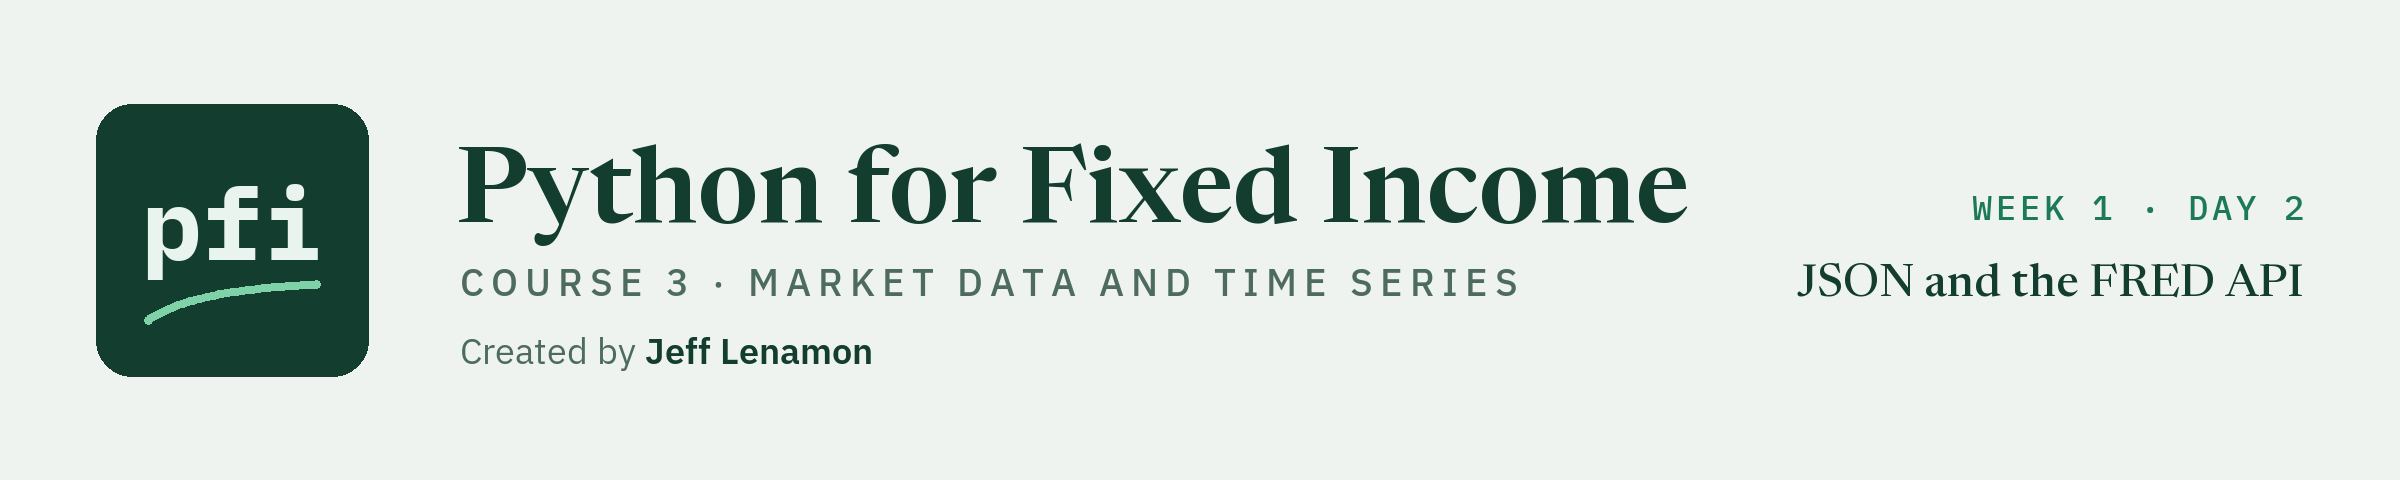

# JSON and the FRED API

Week 1, Day 2. Yesterday's live cell got an answer back from FRED. Today: what that answer is (JSON), how FRED marks a day with no value and why it must never become zero, and the three functions that turn a FRED request into a dated series, with errors that never show your key.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course3_market_data/week1/day2/02_json_and_the_fred_api.ipynb)

Day 1 sent one request to FRED and turned the answer into a table in a single cell. Today that cell becomes three tested functions in `marketdata.py`, and every step gets a closer look.

The answer FRED sends is **JSON**, a text format for data that nearly every web API uses, and that AI assistants use when you ask them for structured answers. Inside FRED's answer, each observation's value is text, and a weekday with no value holds a single dot, `"."`. A dot is easy to turn into a zero by accident, and a zero in a yield series is a change of hundreds of basis points that never happened.

Today you will:

1. Read JSON with `json.loads`: objects, lists, and the Python types they become.
2. Read FRED's answer, from a sample file in FRED's format with Treasury's values.
3. See what `"."` does to a calculation, and keep it as `NaN`.
4. Write `fred_params` and `parse_fred_observations`, docstring first, with tests.
5. Write `fred_series`, the one network function in the module, and see why it never calls `raise_for_status`.
6. Pull the 10-year and 2-year yields live from 2015 and check them against the Treasury file on every common date.

**No key? Run everything anyway.** Every cell runs without a key. Three live cells print the skip message, and the saved outputs are exactly that run. Every demo of an error uses the course's fake key, `fakefakefakefakefakefakefakefake`.

The setup cell is day 1's. It copies three data files today, and writes `marketdata.py` and `test_marketdata.py` as they stood at the end of day 1, so this notebook does not depend on yesterday's.

Q. Set up today's work folder and copy today's three data files into it.

In [1]:
# today's setup: modules, the course data, a fresh work folder, and the constants the live cells use
import importlib
import os
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import pandas as pd

# three packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("pytest", "pytest"), ("requests", "requests"), ("dotenv", "python-dotenv")]:
    try:
        importlib.import_module(module_name)
    except ImportError:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.") from None
import pytest
import requests

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "treasury_par_yields.csv").exists()
data_folder = RAW_DATA if on_github else str(local_data) + os.sep

# 2. your own key file: in your my_bondmath folder, outside every repository. Its path is never printed.
ENV_FILE = Path.home() / "projects" / "my_bondmath" / ".env"

# 3. the two constants of the live cells
NO_KEY_MESSAGE = "Live cell skipped: no FRED key was found. Every other cell runs without one."
# ICE BofA and Moody's values stay off the screen unless you set this to True, on your own machine only
SHOW_LICENSED_VALUES = False

# 4. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course3_02_"))
os.chdir(work)

# 5. copy today's data files into the work folder
DATA_FILES = ["treasury_par_yields.csv", "course3_fred_format_dgs10.json", "course3_fred_format_dgs2.json"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES) or 'none'}")
print(f"pytest {pytest.__version__}, requests {requests.__version__}")

Work folder: pfi_course3_02_v553tpea, in your temp folder
Data files from the data folder of the course repo: treasury_par_yields.csv, course3_fred_format_dgs10.json, course3_fred_format_dgs2.json
pytest 9.1.1, requests 2.34.2


Q. Write `bondmath.py`, the reference copy of the module you finished in Course 2.

It is written into the work folder so that every notebook runs, in Colab too, whether or not you took Course 2. To use your own copy instead, run this line in a new cell after the next one:

```python
shutil.copy(Path.home() / "projects" / "my_bondmath" / "bondmath.py", work)
```

The saved outputs of this notebook always come from the reference copy.

In [2]:
%%writefile bondmath.py
"""bondmath: bond math for fixed-rate bullet bonds, checked against Excel.

Written day by day in Python for Fixed Income, Course 2: Bond Math.

Units, the same in every function:
- coupon_pct and yield_pct are annual rates in percent: 7.0 means 7 percent. Excel takes decimals (0.07).
- Prices and accrued interest are per 100 of face.
- Durations are in years, convexity in years squared, spreads in basis points.
- frequency is the number of coupons (or compounding periods) a year: 1, 2, or 4.
- basis is the day count: "30/360" (Excel basis 0) or "ACT/ACT" (Excel basis 1).
- Dates are datetime.date values.
"""
import calendar  # month lengths, used from week 2
from datetime import date  # calendar dates, used from week 2


def future_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Grow an amount at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount x (1 + rate / frequency) ** (frequency x years).
    Excel: =FV(rate_pct/100/frequency, frequency*years, 0, -amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # grow the amount over every period
    return amount * (1 + period_rate) ** periods


def present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # discount the amount over every period
    return amount / (1 + period_rate) ** periods


def cash_flows(coupon_pct: float, years: float, frequency: int = 2) -> list[tuple[float, float]]:
    """The cash flows of a bullet bond bought on a coupon date.

    Units: coupon_pct in percent of face a year, years in years. Each cash flow is per 100 of face.
    Convention: one coupon of coupon_pct / frequency every 1 / frequency years, and 100 back with
    the last coupon. Returns a list of (time in years, cash flow) pairs, earliest first.
    Raises ValueError unless years x frequency is a whole number of periods.
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # count the coupon periods and check they are whole
    periods = years * frequency
    if periods <= 0 or abs(periods - round(periods)) > 1e-9:
        raise ValueError(f"{years} years is not a whole number of periods at frequency {frequency}")
    periods = round(periods)
    # each coupon is the annual coupon split into equal parts
    coupon = coupon_pct / frequency
    flows = []
    for k in range(1, periods + 1):
        # the time of payment k, in years
        time_years = k / frequency
        # the last payment also returns the face of 100
        amount = coupon + 100 if k == periods else coupon
        flows.append((time_years, amount))
    return flows


def price_from_yield(coupon_pct: float, yield_pct: float, years: float, frequency: int = 2) -> float:
    """Price of a bullet bond on a coupon date, from its yield.

    Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
    Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
    On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
    Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # the yield for one period, as a decimal
    period_yield = yield_pct / 100 / frequency
    price = 0.0
    for time_years, amount in cash_flows(coupon_pct, years, frequency):
        # discount each cash flow by one factor per period until it is paid
        price += amount / (1 + period_yield) ** (time_years * frequency)
    return price


def convert_yield(yield_pct: float, from_frequency: int, to_frequency: int) -> float:
    """The same yield restated at another compounding frequency.

    Units: yield_pct in percent a year; the result is in percent a year.
    Convention: both rates grow 100 to the same amount in one year.
    Excel: convert_yield(y, f, 1) is =EFFECT(y/100, f)*100, and convert_yield(y, 1, f) is =NOMINAL(y/100, f)*100.
    """
    # stop on a frequency the course does not use
    for frequency in (from_frequency, to_frequency):
        if frequency not in (1, 2, 4):
            raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # how much 1 grows to in one year at the original frequency
    growth_one_year = (1 + yield_pct / 100 / from_frequency) ** from_frequency
    # the rate per period at the new frequency that gives the same growth
    period_rate = growth_one_year ** (1 / to_frequency) - 1
    # back to an annual rate in percent
    return period_rate * to_frequency * 100


def yield_from_price(coupon_pct: float, price: float, years: float, frequency: int = 2) -> float:
    """Yield of a bullet bond on a coupon date, from its price, by bisection.

    Units: coupon_pct in percent a year, price per 100 of face, years in years; the result is in percent.
    Convention: the yield, compounded `frequency` times a year, at which price_from_yield equals price.
    The search runs between -5 and 100 percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Excel: =RATE(frequency*years, coupon_pct/frequency, -price, 100)*frequency, then x 100.
    """
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price_from_yield(coupon_pct, low_pct, years, frequency)
    lowest_price = price_from_yield(coupon_pct, high_pct, years, frequency)
    if not lowest_price <= price <= highest_price:
        raise ValueError(f"price {price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price_from_yield(coupon_pct, mid_pct, years, frequency) > price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def add_months(d: date, months: int) -> date:
    """Move a date by whole months, keeping the day of the month where the month allows it.

    Units: d is a date, months a whole number (negative moves back).
    Convention: the day is clamped to the length of the new month, so 31 August minus 6 months is
    28 February (29 February in a leap year). Excel: =EDATE(d, months)
    """
    # count months from year 0 so the year and month come out of one division
    month_index = d.year * 12 + (d.month - 1) + months
    year, month_zero_based = divmod(month_index, 12)
    month = month_zero_based + 1
    # the number of days in the new month
    days_in_month = calendar.monthrange(year, month)[1]
    # keep the day, or use the last day of a shorter month
    return date(year, month, min(d.day, days_in_month))


def coupon_dates(settlement: date, maturity: date, frequency: int = 2) -> list[date]:
    """The previous coupon date, then every coupon date left through maturity.

    Units: dates. Convention: coupon dates are counted back from maturity in steps of 12 / frequency
    months, each one computed from maturity directly, so a 31st never drifts to the 28th. If maturity
    is the last day of its month, every coupon date is the last day of its month (Excel's rule).
    The previous coupon date is the last one on or before settlement.
    So [0] is Excel's COUPPCD, [1] is COUPNCD, and len - 1 is COUPNUM.
    """
    # stop on bad input
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # months between coupons
    step_months = 12 // frequency
    # does the bond mature on the last day of a month?
    month_end = maturity.day == calendar.monthrange(maturity.year, maturity.month)[1]
    dates = []
    k = 0
    while True:
        # coupon k steps back from maturity, computed from maturity itself
        coupon_date = add_months(maturity, -k * step_months)
        if month_end:
            # the month-end rule: move to the last day of that month
            last_day = calendar.monthrange(coupon_date.year, coupon_date.month)[1]
            coupon_date = date(coupon_date.year, coupon_date.month, last_day)
        dates.append(coupon_date)
        # stop once we reach the previous coupon date
        if coupon_date <= settlement:
            break
        k += 1
    # earliest first
    dates.reverse()
    return dates


def days_30_360(start: date, end: date) -> int:
    """Days from start to end on the US 30/360 basis, as Excel's COUPDAYBS and YEARFRAC(..., 0) count them.

    Units: dates in, whole days out. Every month counts as 30 days and every year as 360.
    Convention, with D1 the start day and D2 the end day:
    1. If start is the last day of February, D1 = 30.
    2. If start and end are both the last day of February, D2 = 30.
    3. If D1 is 31, D1 = 30.
    4. If D2 is 31 and the start day was 30 or 31, D2 = 30. (Excel looks at the start date's own
       day here, so a start on 28 February and an end on the 31st keeps D2 = 31.)
    Days = 360 x (Y2 - Y1) + 30 x (M2 - M1) + (D2 - D1).
    Excel's DAYS360 uses different February rules and is not the same count.
    """
    d1, d2 = start.day, end.day
    start_is_feb_end = start.month == 2 and start.day == calendar.monthrange(start.year, 2)[1]
    end_is_feb_end = end.month == 2 and end.day == calendar.monthrange(end.year, 2)[1]
    # rule 1: the last day of February counts as the 30th
    if start_is_feb_end:
        d1 = 30
    # rule 2: both dates on the last day of February
    if start_is_feb_end and end_is_feb_end:
        d2 = 30
    # rule 3: a 31st start counts as the 30th
    if start.day == 31:
        d1 = 30
    # rule 4: a 31st end counts as the 30th when the start day was 30 or 31
    if end.day == 31 and start.day >= 30:
        d2 = 30
    return 360 * (end.year - start.year) + 30 * (end.month - start.month) + (d2 - d1)


def coupon_period_days(settlement: date, maturity: date, frequency: int = 2,
                       basis: str = "30/360") -> tuple[int, int, int]:
    """Day counts of the coupon period that holds settlement: (A, E, DSC).

    Units: whole days.
    A is days from the previous coupon to settlement (Excel COUPDAYBS).
    E is days in the coupon period: 360 / frequency under 30/360 (Excel COUPDAYS), and the actual days
    from the previous to the next coupon under ACT/ACT.
    DSC is days from settlement to the next coupon, as Excel's PRICE uses it: E - A under 30/360
    (this can differ from COUPDAYSNC near the end of February), actual days under ACT/ACT.
    """
    # stop on a basis the course does not use (coupon_dates checks frequency and dates)
    if basis not in ("30/360", "ACT/ACT"):
        raise ValueError(f'basis must be "30/360" or "ACT/ACT", not {basis!r}')
    # the previous and next coupon dates
    dates = coupon_dates(settlement, maturity, frequency)
    previous_coupon, next_coupon = dates[0], dates[1]
    if basis == "30/360":
        # 30/360: A by the 30/360 rules, a fixed period length, and DSC as what is left of it
        days_accrued = days_30_360(previous_coupon, settlement)
        days_in_period = 360 // frequency
        days_to_next = days_in_period - days_accrued
    else:
        # ACT/ACT: every count is actual calendar days
        days_accrued = (settlement - previous_coupon).days
        days_in_period = (next_coupon - previous_coupon).days
        days_to_next = (next_coupon - settlement).days
    return days_accrued, days_in_period, days_to_next


def accrued_interest(settlement: date, maturity: date, coupon_pct: float, frequency: int = 2,
                     basis: str = "30/360") -> float:
    """Accrued interest the buyer pays the seller, per 100 of face.

    Units: coupon_pct in percent a year; the result is per 100 of face.
    Convention: coupon_pct / frequency x A / E, with A and E from coupon_period_days.
    Excel (30/360): =100*coupon_pct/100/frequency*COUPDAYBS(...)/COUPDAYS(...)
    """
    # A and E for this settlement
    days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
    # one coupon, times the share of the period that has passed
    return coupon_pct / frequency * days_accrued / days_in_period


def price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
          basis: str = "30/360") -> float:
    """Clean price per 100 of face on any settlement date, as Excel's PRICE.

    Units: coupon_pct and yield_pct in percent a year; the result is a clean price per 100 of face.
    Convention: yield compounded `frequency` times a year. w = DSC / E is the part of a period left
    until the next coupon. Dirty price = sum over the N coupons left of CF_k / (1 + y/f) ** (w + k).
    In the final coupon period (N = 1) Excel uses simple interest: dirty = (100 + CF) / (1 + w x y/f).
    Clean = dirty - accrued interest.
    Excel: =PRICE(settlement, maturity, coupon_pct/100, yield_pct/100, 100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    days_accrued, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    # coupons left, the fraction of a period to the next one, the period yield, and one coupon
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    if coupons_left == 1:
        # final period: simple interest on the last coupon and the face
        dirty = (100 + coupon) / (1 + w * period_yield)
    else:
        dirty = 0.0
        for k in range(coupons_left):
            # the last cash flow also returns the face
            cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
            dirty += cash_flow / (1 + period_yield) ** (w + k)
    # the quote is clean: take off the accrued interest
    return dirty - accrued_interest(settlement, maturity, coupon_pct, frequency, basis)


def dirty_price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                basis: str = "30/360") -> float:
    """Dirty (full, invoice) price per 100 of face: the clean price plus accrued interest.

    Units and convention as price(). Excel: =PRICE(...) + the accrued formula.
    """
    # clean price plus accrued interest
    return (price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
            + accrued_interest(settlement, maturity, coupon_pct, frequency, basis))


def yield_to_maturity(settlement: date, maturity: date, coupon_pct: float, clean_price: float,
                      frequency: int = 2, basis: str = "30/360") -> float:
    """Yield in percent from a clean price on any settlement date, by bisection, as Excel's YIELD x 100.

    Units: coupon_pct in percent a year, clean_price per 100 of face; the result is in percent a year.
    Convention: the yield at which price() equals clean_price. The search runs between -5 and 100
    percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Final coupon period: Excel's YIELD uses a formula instead of a search, with DSR, the days from
    settlement to maturity, counted by days_30_360 under 30/360 (actual days under ACT/ACT):
    yield = ((100 + CF) - dirty) / dirty x frequency x E / DSR. Under 30/360 DSR can differ from the
    E - A that PRICE uses, so in those cases YIELD does not return the yield PRICE was given.
    Excel: =YIELD(settlement, maturity, coupon_pct/100, clean_price, 100, frequency, basis)*100
    """
    # final coupon period: Excel's formula (coupon_dates and coupon_period_days check the inputs)
    if len(coupon_dates(settlement, maturity, frequency)) - 1 == 1:
        days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
        if basis == "30/360":
            days_to_maturity = days_30_360(settlement, maturity)
        else:
            days_to_maturity = (maturity - settlement).days
        coupon = coupon_pct / frequency
        # the dirty price paid, and what comes back at maturity
        paid = clean_price + coupon * days_accrued / days_in_period
        received = 100 + coupon
        # the simple return over the days left, made annual, in percent
        return (received - paid) / paid * frequency * days_in_period / days_to_maturity * 100
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price(settlement, maturity, coupon_pct, low_pct, frequency, basis)
    lowest_price = price(settlement, maturity, coupon_pct, high_pct, frequency, basis)
    if not lowest_price <= clean_price <= highest_price:
        raise ValueError(f"price {clean_price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price(settlement, maturity, coupon_pct, mid_pct, frequency, basis) > clean_price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def macaulay_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Macaulay duration in years: the present-value weighted average time of the cash flows.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: t_k = (w + k) / frequency years, PV_k = CF_k / (1 + y/f) ** (w + k), and
    duration = sum of t_k x PV_k / sum of PV_k. In the final period this is DSC / E / frequency.
    Excel: =DURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, weighted_time = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow, its time in years, and its present value
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        pv = cash_flow / (1 + period_yield) ** (w + k)
        total_pv += pv
        weighted_time += time_years * pv
    # the weighted average time
    return weighted_time / total_pv


def modified_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Modified duration in years: the percent price change for a 1-point (100 bp) change in yield.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: Macaulay duration / (1 + y / frequency), with y = yield_pct / 100.
    Excel: =MDURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # divide Macaulay duration by one plus the period yield
    period_yield = yield_pct / 100 / frequency
    return macaulay_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis) / (1 + period_yield)


def dv01(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
         basis: str = "30/360") -> float:
    """DV01: price points per 100 of face for a 1 basis point fall in yield, positive for a long position.

    Units: coupon_pct and yield_pct in percent a year; the result is in price points per 100 of face per bp.
    Convention: modified duration x dirty price x 0.0001. Position DV01 in dollars = dv01 x par / 100.
    Excel: =MDURATION(...)*(PRICE(...)+accrued)/10000
    """
    # modified duration times the dirty price, for one basis point (0.0001 as a decimal)
    duration_years = modified_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    full_price = dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    return duration_years * full_price * 0.0001


def convexity(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
              basis: str = "30/360") -> float:
    """Convexity in years squared, unscaled (not divided by 100 or by 2).

    Units: coupon_pct and yield_pct in percent a year; the result is in years squared.
    Convention: (1 / P) x sum of CF_k x t_k x (t_k + 1/f) / (1 + y/f) ** (f t_k + 2), where
    t_k = (w + k) / f and P is the sum of the discounted cash flows. Price change estimate:
    dP / P = -D_mod x dy + 0.5 x convexity x dy ** 2, with dy in decimal.
    Excel has no convexity function; the check is a central difference on three PRICE cells.
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, curvature = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow and its time in years
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        # its present value, and its term in the convexity sum
        total_pv += cash_flow / (1 + period_yield) ** (w + k)
        curvature += (cash_flow * time_years * (time_years + 1 / frequency)
                      / (1 + period_yield) ** (frequency * time_years + 2))
    # divide by the price
    return curvature / total_pv


def interpolate_yield(tenor_years: float, curve_tenors: list[float], curve_yields_pct: list[float]) -> float:
    """Yield at any tenor by straight-line interpolation on a curve, flat beyond its ends.

    Units: tenors in years, yields in percent; the result is in percent.
    Convention: linear in yield against tenor between the two curve points around tenor_years. Below
    the first tenor the first yield is used, above the last tenor the last yield (as numpy.interp).
    Raises ValueError if the lists differ in length, are empty, or the tenors do not ascend.
    """
    # stop on a curve the function cannot read
    if len(curve_tenors) != len(curve_yields_pct) or len(curve_tenors) == 0:
        raise ValueError("curve_tenors and curve_yields_pct must be non-empty and the same length")
    for i in range(1, len(curve_tenors)):
        if curve_tenors[i] <= curve_tenors[i - 1]:
            raise ValueError(f"curve tenors must ascend: {curve_tenors[i - 1]} then {curve_tenors[i]}")
    # flat beyond the ends
    if tenor_years <= curve_tenors[0]:
        return curve_yields_pct[0]
    if tenor_years >= curve_tenors[-1]:
        return curve_yields_pct[-1]
    # find the two tenors around tenor_years
    i = 1
    while curve_tenors[i] < tenor_years:
        i += 1
    left_tenor, right_tenor = curve_tenors[i - 1], curve_tenors[i]
    left_yield, right_yield = curve_yields_pct[i - 1], curve_yields_pct[i]
    # move along the straight line between them
    slope = (right_yield - left_yield) / (right_tenor - left_tenor)
    return left_yield + slope * (tenor_years - left_tenor)


def years_to_maturity(settlement: date, maturity: date) -> float:
    """Years from settlement to maturity on the US 30/360 basis.

    Units: dates in, years out. Convention: days_30_360(settlement, maturity) / 360, the rule the
    holdings file used to read the curve. Excel: =YEARFRAC(settlement, maturity, 0)
    """
    # stop on dates in the wrong order
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # 30/360 days over a 360-day year
    return days_30_360(settlement, maturity) / 360


def spread_to_curve_bp(yield_pct: float, years: float, curve_tenors: list[float],
                       curve_yields_pct: list[float]) -> float:
    """Yield spread over a curve at the bond's own maturity, in basis points.

    Units: yield_pct and curve yields in percent, years and tenors in years; the result is in bp.
    Convention: (yield_pct - the curve interpolated at `years`) x 100. A yield spread at the same
    maturity, not an option-adjusted spread from a spot curve.
    """
    # the curve yield at the bond's maturity
    curve_yield_pct = interpolate_yield(years, curve_tenors, curve_yields_pct)
    # the gap in percent, times 100 basis points per percent
    return (yield_pct - curve_yield_pct) * 100


def spread_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                    basis: str = "30/360", bump_bp: float = 1.0) -> float:
    """Spread duration in years: the percent price change for a 100 bp move in the spread.

    Units: coupon_pct and yield_pct in percent a year, bump_bp in basis points; the result is in years.
    Convention: the yield is curve plus spread, so a spread move is a yield move. Central difference:
    (price at spread - bump minus price at spread + bump) / (2 x bump as a decimal) / dirty price.
    Accrued interest does not change with the spread, so clean price differences equal dirty ones.
    Excel: =(PRICE(...,yld-0.0001,...)-PRICE(...,yld+0.0001,...))/(2*0.0001)/(PRICE(...)+accrued)
    """
    # stop on a bump that cannot measure a slope
    if bump_bp <= 0:
        raise ValueError(f"bump_bp must be positive, not {bump_bp}")
    # the bump in percent (for yield_pct) and as a decimal (for the slope)
    bump_pct = bump_bp / 100
    bump_decimal = bump_bp / 10000
    # reprice with the spread down and up
    price_spread_down = price(settlement, maturity, coupon_pct, yield_pct - bump_pct, frequency, basis)
    price_spread_up = price(settlement, maturity, coupon_pct, yield_pct + bump_pct, frequency, basis)
    full_price = dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    # the slope of price against spread, as a share of the dirty price
    return (price_spread_down - price_spread_up) / (2 * bump_decimal) / full_price


def dts(spread_duration_years: float, spread_bp: float) -> float:
    """Duration times spread (DTS), a published measure of spread risk.

    Units: spread duration in years, spread in basis points; the result is in years times bp.
    Convention: spread_duration_years x spread_bp.
    """
    # the product of the two
    return spread_duration_years * spread_bp


def weighted_average(values: list[float], weights: list[float]) -> float:
    """Weighted average of values.

    Units: the result has the units of the values; weights in any one unit (market value in dollars
    for a book). Convention: sum of value x weight / sum of weights. Excel: =SUMPRODUCT(values, weights)/SUM(weights)
    Raises ValueError if the lists differ in length or the weights sum to zero.
    """
    # stop on lists that do not line up, or weights with nothing in them
    if len(values) != len(weights):
        raise ValueError(f"{len(values)} values but {len(weights)} weights")
    total_weight = sum(weights)
    if total_weight == 0:
        raise ValueError("the weights sum to zero")
    # sum of value times weight
    total = 0.0
    for value, weight in zip(values, weights):
        total += value * weight
    return total / total_weight


def price_change_estimate(dirty_price: float, modified_duration: float, convexity: float, shift_bp: float) -> float:
    """Estimated change in price from duration and convexity, per 100 of face.

    Units: dirty_price per 100 of face, modified_duration in years, convexity in years squared,
    shift_bp in basis points (positive means yields up). The result is in price points per 100 of face.
    Convention: dirty_price x (-modified_duration x dy + 0.5 x convexity x dy ** 2), with dy = shift_bp / 10000.
    """
    # the yield change as a decimal
    dy = shift_bp / 10000
    # the duration term and the convexity term, times the price
    return dirty_price * (-modified_duration * dy + 0.5 * convexity * dy ** 2)

Writing bondmath.py


Q. Write `marketdata.py` and `test_marketdata.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [3]:
%%writefile marketdata.py
"""marketdata: dated market series for fixed income, checked against Excel.

Written day by day in Python for Fixed Income, Course 3: Market Data and Time Series.

Conventions, the same in every function:
- A series has a DatetimeIndex named date: naive calendar dates (no time, no time zone), unique and ascending.
- Yields are in percent (5.29 means 5.29 percent), as Treasury and FRED publish them. Spreads are in basis points.
- Changes of yields and spreads are in basis points. Price changes are simple returns in percent.
- Windows are counted in observations (rows of the market calendar), trailing, and include the current row.
- A missing observation is NaN. It is dropped before any change or window is computed, never filled.
- A secret (an API key) is never printed, written to a file, or put in an error message.
"""
import os  # environment variables
from pathlib import Path  # file paths


def get_secret(name: str, env_file: str | Path) -> str:
    """Return a secret such as an API key, looked up in three places in a fixed order.

    Units: none; the secret is text. Convention: the first place that holds a non-empty value wins:
    1. the environment variable `name`;
    2. Colab's Secrets panel (google.colab.userdata), only when running in Colab;
    3. the .env file at `env_file`, read with dotenv.dotenv_values, which does not change os.environ.
    The value is returned and never printed. Raises RuntimeError naming the secret and the three places
    looked, never a value and never the full path of the file.
    """
    # 1. the environment: a variable set in PowerShell, or by the program that started Python
    value = os.environ.get(name)
    if value:
        return value

    # 2. Colab's Secrets panel: the import works only inside Colab
    try:
        from google.colab import userdata
    except ImportError:
        userdata = None
    if userdata is not None:
        try:
            value = userdata.get(name)
        # a secret that is not there, or one the notebook has not been given access to
        except (userdata.SecretNotFoundError, userdata.NotebookAccessError):
            value = None
        if value:
            return value

    # 3. the .env file, imported here so Colab never needs python-dotenv
    env_path = Path(env_file)
    if env_path.is_file():
        from dotenv import dotenv_values
        value = dotenv_values(env_path).get(name)
        if value:
            return value

    # nothing found: say where we looked, with the file's name only (a full path shows a user name)
    raise RuntimeError(
        f"Secret {name} not found. Looked in: the environment variable {name}, "
        f"Colab's Secrets panel, and the file {env_path.name} given as env_file."
    )

Writing marketdata.py


In [4]:
%%writefile test_marketdata.py
"""Tests for marketdata.py.

Expected values come from Excel (course3_excel_reference.csv in this folder), from the course's data files, or
from small hand examples. No test touches the network or needs a real key: the only key is the course's fake one.
Run from this folder with:  python -m pytest
"""
import pytest

import marketdata as md

# the course's fake key: 32 lowercase letters, the shape FRED expects, obviously not a key
FAKE_KEY = "fakefakefakefakefakefakefakefake"
# the demo name; never FRED_API_KEY, because get_secret checks the environment first
DEMO_NAME = "DEMO_API_KEY"


def test_get_secret_reads_environment(monkeypatch, tmp_path):
    # monkeypatch sets the variable for this test only and removes it afterwards
    monkeypatch.setenv(DEMO_NAME, FAKE_KEY)
    assert md.get_secret(DEMO_NAME, env_file=tmp_path / ".env") == FAKE_KEY


def test_get_secret_reads_env_file(monkeypatch, tmp_path):
    # no variable in the environment, so the file is used
    monkeypatch.delenv(DEMO_NAME, raising=False)
    env_file = tmp_path / ".env"
    env_file.write_text(f"{DEMO_NAME}={FAKE_KEY}\n", encoding="utf-8")
    assert md.get_secret(DEMO_NAME, env_file=env_file) == FAKE_KEY


def test_get_secret_environment_wins(monkeypatch, tmp_path):
    # both places hold a value: the environment comes first
    env_file = tmp_path / ".env"
    env_file.write_text(f"{DEMO_NAME}=value-from-the-file\n", encoding="utf-8")
    monkeypatch.setenv(DEMO_NAME, FAKE_KEY)
    assert md.get_secret(DEMO_NAME, env_file=env_file) == FAKE_KEY


def test_get_secret_missing_raises_without_value(monkeypatch, tmp_path):
    # the file holds a different secret; the one asked for is nowhere
    monkeypatch.delenv(DEMO_NAME, raising=False)
    env_file = tmp_path / ".env"
    env_file.write_text(f"OTHER_API_KEY={FAKE_KEY}\n", encoding="utf-8")
    with pytest.raises(RuntimeError) as caught:
        md.get_secret(DEMO_NAME, env_file=env_file)
    message = str(caught.value)
    # the message names the secret and the places looked, and holds no value and no folder
    assert DEMO_NAME in message and "environment" in message and ".env" in message
    assert FAKE_KEY not in message
    assert str(tmp_path) not in message

Writing test_marketdata.py


Q. Import the modules.

In [5]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import bondmath
import marketdata as md
# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(bondmath)
importlib.reload(md)
# the functions defined in each module itself, not the ones it imports
def own_functions(module):
    return [name for name, obj in vars(module).items() if callable(obj) and getattr(obj, "__module__", "") == module.__name__]

print(f"bondmath (the Course 2 reference): {len(own_functions(bondmath))} functions")
print(f"marketdata functions: {own_functions(md)}")

bondmath (the Course 2 reference): 25 functions
marketdata functions: ['get_secret']


* `marketdata` starts the day with day 1's one function, `get_secret`.

Q. Make the work folder a repository and commit yesterday's two files, as your own `my_bondmath` folder already holds them. Then today's work shows up as changes to them.

In [6]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [7]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course3_02_v553tpea and nowhere else


In [8]:
%%writefile .gitignore
.env
cache/
*.db
__pycache__/
.pytest_cache/

Writing .gitignore


In [9]:
# yesterday's files, committed as they were at the end of day 1
!git -C "{work}" add .gitignore marketdata.py test_marketdata.py
!git -C "{work}" commit -q -m "Day 1: get_secret and its tests"
!git -C "{work}" log --oneline

cee22f5 Day 1: get_secret and its tests


* One commit: day 1's module and tests. The Git section at the end reads today's changes against it.

## 2.1 JSON: Objects, Lists, and `json.loads`

JSON (JavaScript Object Notation) writes data as plain text with two containers:

* an **object**, `{ }`, holds `"name": value` pairs, like a Python dictionary;
* a **list**, `[ ]`, holds values in order, like a Python list.

Inside them are text in double quotes, numbers, `true`, `false`, and `null`. That is the whole format. Because it is plain text with so few rules, a program in any language can read it, which is why web APIs answer in it, and why an AI assistant asked for a structured answer usually replies in it (day 13 checks such replies).

Q. Here is a small JSON text written for this example, in the shape of FRED's answer, with two 10-year yields from the Treasury file. Read it with `json.loads`.

In [10]:
import json

# JSON is text: one Python string holding an object, with a list inside it
text = '{"series_id": "DGS10", "units": "Percent", "complete": true, "notes": null, "observations": [{"date": "2026-09-29", "value": "5.26"}, {"date": "2026-09-30", "value": "5.29"}]}'

# json.loads ("load string") turns the text into Python objects
reply = json.loads(text)
print(f"reply is a {type(reply).__name__} with names {list(reply)}")
print(f"observations is a {type(reply['observations']).__name__} of {len(reply['observations'])} dictionaries")

reply is a dict with names ['series_id', 'units', 'complete', 'notes', 'observations']
observations is a list of 2 dictionaries


Q. What Python type does each JSON value become?

In [11]:
# true and null are JSON words; json.loads turns them into True and None
print(f"complete: {reply['complete']!r} ({type(reply['complete']).__name__})")
print(f"notes: {reply['notes']!r}")

# the last observation's value, as JSON wrote it
last_value = reply["observations"][-1]["value"]
print(f"last value: {last_value!r} ({type(last_value).__name__})")

complete: True (bool)
notes: None
last value: '5.29' (str)


| JSON | Python |
| --- | --- |
| object `{ }` | `dict` |
| list `[ ]` | `list` |
| `"text"` | `str` |
| `5` or `5.29` | `int` or `float` |
| `true`, `false` | `True`, `False` |
| `null` | `None` |

* The value `"5.29"` is in double quotes, so it is **text**, not a number. FRED sends every value this way. Turning text into numbers is the parser's job, in section 2.4.

Q. And back again: turn the dictionary into JSON text with `json.dumps`, indented for reading.

In [12]:
# json.dumps ("dump string") writes JSON text; indent=2 puts each item on its own line
print(json.dumps(reply["observations"][-1], indent=2))

{
  "date": "2026-09-30",
  "value": "5.29"
}


Q. A Python dictionary printed with `print` looks a lot like JSON. Is it JSON?

In [13]:
# str() of a dictionary uses single quotes; JSON needs double quotes
python_text = str(reply["observations"][-1])
print(python_text)
try:
    json.loads(python_text)
except json.JSONDecodeError as error:
    # the error's own message, without the long trace through the json library
    print(f"JSONDecodeError: {error}")

{'date': '2026-09-30', 'value': '5.29'}
JSONDecodeError: Expecting property name enclosed in double quotes: line 1 column 2 (char 1)


* No. JSON names must be in double quotes, and Python's printout uses single quotes, so `json.loads` stops at the first character after the brace. When code or an assistant hands you "JSON", read it with `json.loads`: if it is not JSON, you find out at once.

## 2.2 The FRED Response

> **Story: from a bulletin board to an API.** FRED's own help pages say that "Before the popularization of the World Wide Web, the data were provided in list form on a dial-in, electronic bulletin board system." The same data now comes back as JSON from a URL. Source: FRED Help, "What is FRED?", https://fredhelp.stlouisfed.org/fred/about/about-fred/what-is-fred/ (read 2026-10-04).

The course's sample, `course3_fred_format_dgs10.json`, is an answer in FRED's format for series `DGS10` from 2026-08-03 to 2026-09-30. It was **built for this course from the Treasury file**: the layout is FRED's, the values are Treasury's, and nothing in it was downloaded from FRED. It lets every cell today run with no key and no network.

Q. Read the sample. What names does the top-level object hold?

In [14]:
# the whole answer is one JSON object
payload = json.loads(Path("course3_fred_format_dgs10.json").read_text(encoding="utf-8"))

# every name except the observations, with its value
for name, value in payload.items():
    if name != "observations":
        print(f"{name:>17}: {value}")
print(f"{'observations':>17}: a list of {len(payload['observations'])}")

   realtime_start: 2026-10-02
     realtime_end: 2026-10-02
observation_start: 2026-08-03
  observation_end: 2026-09-30
            units: lin
      output_type: 1
        file_type: json
         order_by: observation_date
       sort_order: asc
            count: 43
           offset: 0
            limit: 100000
     observations: a list of 43


| Name | What it says |
| --- | --- |
| `realtime_start`, `realtime_end` | FRED's real-time period: which vintage of the data the answer reflects. By default both are the day of the request. This course does not use them. |
| `observation_start`, `observation_end` | The dates asked for, or the series' first and last date when none are asked for |
| `units` | `lin`: levels, the values as published, with no transformation (FRED can return changes instead) |
| `output_type`, `file_type`, `order_by`, `sort_order` | How the answer is laid out: JSON, by date, oldest first |
| `count` | How many observations FRED found |
| `offset`, `limit` | Paging: FRED returns at most `limit` observations (100,000 by default), starting at `offset` |
| `observations` | The data: a list of small objects |

FRED's documentation of this endpoint lists every parameter: https://fred.stlouisfed.org/docs/api/fred/series_observations.html.

Q. Look at the observations as a table. What type is each column?

In [15]:
# one row per observation; the four names become the columns
obs = pd.DataFrame(payload["observations"])
print(obs.dtypes.to_string())
print(f"{len(obs)} rows; count says {payload['count']}")

realtime_start    str
realtime_end      str
date              str
value             str
43 rows; count says 43


* Every column is text (`str`), dates and values included, and the row count matches `count`.

Q. Show the rows around Labor Day, 2026-09-07.

In [16]:
obs.iloc[23:28]

,realtime_start,realtime_end,date,value
23,2026-10-02,2026-10-02,2026-09-03,4.77
24,2026-10-02,2026-10-02,2026-09-04,4.78
25,2026-10-02,2026-10-02,2026-09-07,.
26,2026-10-02,2026-10-02,2026-09-08,4.80
27,2026-10-02,2026-10-02,2026-09-09,4.83


* 2026-09-07 is a Monday, a weekday, so FRED has a row for it, and its value is `"."`: no value that day. Weekends have no row at all in the Treasury series.
* The Treasury file has **no row** for 2026-09-07. Same day, two ways of saying "nothing": FRED writes a row with a dot, Treasury leaves the row out. Day 3 compares the two calendars in full.

## 2.3 `.` Is a Missing Value, Never 0

Q. The values are text. Can Python turn `"."` into a number?

In [17]:
# float() turns "4.78" into 4.78, and stops on anything that is not a number
float(".")

ValueError: could not convert string to float: '.'

Q. And pandas, on the whole column?

In [18]:
try:
    pd.to_numeric(obs["value"])
except ValueError as error:
    # the error's own message, without the long trace through pandas
    print(f"ValueError: {error}")

ValueError: Unable to parse string "." at position 25


* Both stop, which is good: an error you can see. The danger is the "fix" that makes the error go away by putting a number where the dot was.

Q. `errors="coerce"` turns anything that is not a number into `NaN`, "not a number", pandas' marker for a missing value. What does the column look like then?

In [19]:
# coerce: a value that cannot be read becomes NaN instead of stopping
values = pd.to_numeric(obs["value"], errors="coerce")
print(f"NaN rows: {values.isna().sum()}, on {obs.loc[values.isna(), 'date'].tolist()}")
print(f"dtype: {values.dtype}")

NaN rows: 1, on ['2026-09-07']
dtype: float64


* One `NaN`, on 2026-09-07, and the column is `float64`: numbers, with the missing day marked as missing.

Q. **Predict** first. Suppose the dot had become `0.0` instead. The 10-year yield was 4.78 percent on Friday 2026-09-04 and 4.80 percent on Tuesday 2026-09-08. What daily change in basis points would that table show for 2026-09-07 and for 2026-09-08?

In [20]:
# two versions of the same three days: the dot kept as NaN, and the dot turned into 0.0
dates = obs["date"].iloc[24:27].tolist()
kept_nan = pd.Series(values.iloc[24:27].tolist(), index=dates)
made_zero = kept_nan.fillna(0.0)

# daily changes in bp; for kept_nan the NaN row is dropped first, so Tuesday's change is from Friday
table = pd.DataFrame({
    "NaN kept (%)": kept_nan,
    "change (bp)": kept_nan.dropna().diff() * 100,
    "dot as 0 (%)": made_zero,
    "change if 0 (bp)": made_zero.diff() * 100,
})
table.round(2)

,NaN kept (%),change (bp),dot as 0 (%),change if 0 (bp)
2026-09-04,4.78,NaN,4.78,NaN
2026-09-07,NaN,NaN,0.00,-478.0
2026-09-08,4.80,2.0,4.80,480.0


* With the dot made `0.0`, the table shows a fall of 478 bp into Labor Day and a rise of 480 bp out of it. Neither happened: the bond market had no 10-year yield that day.
* With the `NaN` dropped first, Tuesday's change is from Friday, the previous observation: 2 bp. That is the course's rule (Course 3 conventions): a change is from the previous row, whatever the calendar gap.

Q. And the average 10-year yield over the sample?

In [21]:
# all of the sample: NaN left out by mean(), against the dot counted as a 0 percent yield
all_values = pd.to_numeric(obs["value"], errors="coerce")
print(f"mean with NaN left out: {all_values.mean():.4f} percent over {all_values.count()} days")
print(f"mean with the dot as 0: {all_values.fillna(0.0).mean():.4f} percent over {len(all_values)} days")

mean with NaN left out: 4.8367 percent over 42 days
mean with the dot as 0: 4.7242 percent over 43 days


* 4.8367 against 4.7242 percent: one zero in 43 rows moves the average by 11.2 bp. pandas leaves `NaN` out of `mean`, `sum`, and `count`, so a missing day stays missing.

**The rule for the whole course:** a `.` becomes `NaN`, never a number. `NaN` rows are dropped, in a step you can see, before any change or window is computed.

## 2.4 `fred_params` and `parse_fred_observations`

Day 1 built the request and read the answer inside one live cell. Now each job gets its own function, so it can be tested without the network. The first builds the parameters of a request. As on day 1, the docstring comes first: it says the dates are text, what is sent when a date is left out, and that the dictionary holds the key and is never printed.

Q. Add the imports today's functions need, FRED's address, and `fred_params` to `marketdata.py`. In your own file you may move the imports to the top.

In [22]:
%%writefile -a marketdata.py


import pandas as pd  # dated series, from day 2
import requests  # HTTP, from day 2

# FRED's endpoint for the observations of one series
FRED_URL = "https://api.stlouisfed.org/fred/series/observations"


def fred_params(series_id: str, api_key: str, start: str | None = None, end: str | None = None) -> dict:
    """The query parameters for one request to FRED's series/observations endpoint.

    Units: start and end are dates as text, YYYY-MM-DD. Convention: JSON is asked for (file_type json);
    a start or end left as None is not sent, so FRED returns the series from its first or to its last date.
    Pure: builds a dict and sends nothing. The dict holds the key, so it is never printed.
    """
    # the three parameters every request needs
    params = {"series_id": series_id, "api_key": api_key, "file_type": "json"}
    # the optional date range
    if start is not None:
        params["observation_start"] = start
    if end is not None:
        params["observation_end"] = end
    return params

Appending to marketdata.py


Q. Reload the module, then build the parameters for the sample's request with the fake key.

In [23]:
# the file changed, so read it again
importlib.reload(md)

# the course's fake key: 32 lowercase letters, the shape FRED expects, obviously not one
FAKE_KEY = "fakefakefakefakefakefakefakefake"
params = md.fred_params("DGS10", FAKE_KEY, start="2026-08-03", end="2026-09-30")

# the names, and a comparison instead of the value: the dictionary holds the key
print(f"names: {list(params)}")
print(f"api_key is the fake key: {params['api_key'] == FAKE_KEY}")

names: ['series_id', 'api_key', 'file_type', 'observation_start', 'observation_end']
api_key is the fake key: True


Q. `requests` turns that dictionary into the `name=value` text after the `?` of the URL. `urlencode`, from the standard library, does the same. What does it make?

In [24]:
from urllib.parse import urlencode

# name=value pairs joined by &: the query part of the request URL, fake key included
print(urlencode(params))

series_id=DGS10&api_key=fakefakefakefakefakefakefakefake&file_type=json&observation_start=2026-08-03&observation_end=2026-09-30


* The key is in that text, as it was in day 1's URL. Printing it is harmless here only because the key is fake. With your key, nothing that holds `params` or the URL is ever printed.

Now the answer. `parse_fred_observations` turns FRED's JSON into a float series indexed by date. Its docstring makes the promise of section 2.3: `"."` becomes `NaN` and is **kept**, so dropping it is a separate step you can see.

Q. Add `parse_fred_observations`.

In [25]:
%%writefile -a marketdata.py


def parse_fred_observations(payload: dict, name: str) -> pd.Series:
    """Turn a FRED series/observations JSON answer into a float series.

    Units: as FRED publishes the series (percent for the Treasury and spread series).
    Convention: one value per observation, indexed by its date (a DatetimeIndex named date). FRED's
    missing marker "." becomes NaN and is kept: dropping it is a separate, visible step.
    Raises ValueError if the answer has no "observations" list.
    """
    # stop on an answer that is not a series/observations answer
    if "observations" not in payload:
        raise ValueError(f"the answer for {name} has no 'observations'; keys are {sorted(payload)}")
    observations = payload["observations"]
    # each date as a calendar date
    dates = pd.to_datetime([obs["date"] for obs in observations], format="%Y-%m-%d")
    # each value as a float; "." is FRED's mark for a day with no value, so it becomes NaN, never 0
    values = [float("nan") if obs["value"] == "." else float(obs["value"]) for obs in observations]
    series = pd.Series(values, index=dates, name=name, dtype="float64")
    series.index.name = "date"
    return series

Appending to marketdata.py

* It stops with a `ValueError` on an answer that has no `observations`, such as one of FRED's error answers, and names the keys it found instead.
* `format="%Y-%m-%d"` tells pandas the exact date layout, so nothing is guessed.

Q. Reload, and parse the sample.

In [26]:
importlib.reload(md)
dgs10 = md.parse_fred_observations(payload, "DGS10")

print(f"{len(dgs10)} rows, {dgs10.isna().sum()} NaN, dtype {dgs10.dtype}, index named {dgs10.index.name!r}")
dgs10.loc["2026-09-03":"2026-09-09"]

43 rows, 1 NaN, dtype float64, index named 'date'


date
2026-09-03    4.77
2026-09-04    4.78
2026-09-07     NaN
2026-09-08    4.80
2026-09-09    4.83
Name: DGS10, dtype: float64

Q. Drop the `NaN` row, in its own visible step, and check the rest against the Treasury file.

In [27]:
# the missing day leaves, and the count says so
dgs10_clean = dgs10.dropna()
print(f"{len(dgs10)} rows before, {len(dgs10_clean)} after dropping NaN")

# the snapshot, with dates as the index; float_precision="round_trip" reads each number exactly as written
treasury = pd.read_csv("treasury_par_yields.csv", parse_dates=["date"], index_col="date", float_precision="round_trip")

# every value against the Treasury file's 10 Yr on the same date, in percent
gap = (dgs10_clean - treasury.loc[dgs10_clean.index, "10 Yr"]).abs().max()
print(f"largest gap to the Treasury file: {gap} percent")
print(f"Labor Day in the Treasury file: {pd.Timestamp('2026-09-07') in treasury.index}")

43 rows before, 42 after dropping NaN
largest gap to the Treasury file: 0.0 percent
Labor Day in the Treasury file: False


* 42 values, each equal to the Treasury file's, and the dropped day is a day the file has no row for.

Q. Add the first three tests of the day. A helper, `read_sample`, reads the sample from the test file's own folder, and `FakeResponse` is a stand-in for an answer from FRED that the error tests in section 2.5 use: a status code, a JSON body, and a URL holding the fake key, with no network.

In [28]:
%%writefile -a test_marketdata.py


import json  # the FRED-format samples, from day 2
import math  # NaN checks, from day 2
import traceback  # what a printed error would show, from day 2
from pathlib import Path  # this folder, from day 2

import pandas as pd  # dated series, from day 2
import requests  # its exception classes, from day 2

# the data files sit in the same folder as this test file
HERE = Path(__file__).parent


def read_sample(series_id: str) -> dict:
    """A FRED-format sample from this folder: Treasury values in FRED's JSON layout, no network."""
    return json.loads((HERE / f"course3_fred_format_{series_id.lower()}.json").read_text(encoding="utf-8"))


class FakeResponse:
    """A stand-in for requests.Response: a status code, a JSON body, and a URL holding the key, no network."""

    def __init__(self, status_code: int, payload: dict):
        self.status_code = status_code
        self.payload = payload
        # a real response's URL holds the key; if fred_series ever printed it, the tests below would catch it
        self.url = f"{md.FRED_URL}?series_id=DGS10&api_key={FAKE_KEY}&file_type=json"

    def json(self) -> dict:
        return self.payload


def test_params_hold_series_and_json():
    params = md.fred_params("DGS10", FAKE_KEY, start="2015-01-01")
    assert params == {"series_id": "DGS10", "api_key": FAKE_KEY, "file_type": "json",
                      "observation_start": "2015-01-01"}
    # no end date asked for, so none is sent
    assert "observation_end" not in params

Appending to test_marketdata.py


In [29]:
%%writefile -a test_marketdata.py


def test_parse_sample_counts_and_nan():
    series = md.parse_fred_observations(read_sample("DGS10"), "DGS10")
    # 43 weekdays from 2026-08-03 to 2026-09-30, one of them FRED's "." on Labor Day
    assert len(series) == 43
    assert series.isna().sum() == 1
    assert math.isnan(series.loc["2026-09-07"])
    assert series.loc["2026-09-30"] == 5.29
    assert series.dtype == "float64"
    assert series.index.name == "date" and series.name == "DGS10"


def test_parse_raises_without_observations():
    with pytest.raises(ValueError):
        md.parse_fred_observations({"error_code": 400, "error_message": "Bad Request."}, "DGS10")

Appending to test_marketdata.py


* `test_params_hold_series_and_json`: the dictionary, and no end date sent when none is given.
* `test_parse_sample_counts_and_nan`: 43 rows, one `NaN` on Labor Day, 5.29 on 2026-09-30, `float64`, the index name.
* `test_parse_raises_without_observations`: one of FRED's error answers stops the parser.

Q. Run the tests.

In [30]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_marketdata.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

.......                                                                  [100%]
7 passed in 0.45s



* `7 passed`: day 1's 4 and today's first 3.

## 2.5 `fred_series`: One GET, Status Codes, and Errors That Hide the Key

`fred_series` joins the two: one GET request with `requests`, then `parse_fred_observations`. It is the only function in the module that uses the network. Most of its lines are about what happens when the answer is not a success.

**Status codes.** 200 means success. FRED answers a bad request with 400 and puts its reason in the body, under `error_message`: a key it does not know, a key of the wrong shape, a series that does not exist (day 1's table). More than 120 requests in a minute gets 429.

**Why never `raise_for_status`.** `requests` has a method, `response.raise_for_status()`, that raises an error for any status of 400 or more. It appears in many tutorials and AI answers. Its message names the full URL, and the URL holds the key. Built here with a stand-in answer and the fake key, the message reads:

```
400 Client Error: Bad Request for url: https://api.stlouisfed.org/fred/series/observations?series_id=DGS10&api_key=fakefakefakefakefakefakefakefake&file_type=json
```

Printed, logged, or pasted into a chat to ask for help, that message gives your key away. A connection error from `requests` carries the URL in its message too. So `fred_series`:

1. never calls `raise_for_status`;
2. on any status other than 200, raises its own `RuntimeError` with the status and FRED's own message (FRED's messages do not repeat the key, and the function replaces it with `***` in case one ever does);
3. on a connection problem, raises a `RuntimeError` that names only the kind of error;
4. raises both `from None`, so Python does not print the original error, URL and all, underneath;
5. stops on an answer with no observations, because FRED answers a date range a series does not cover with status 200 and an empty list.

Q. Add `fred_series`. Read the docstring first: it lists every one of those promises.

In [31]:
%%writefile -a marketdata.py


def fred_series(series_id: str, api_key: str, start: str | None = None, end: str | None = None,
                timeout: float = 30) -> pd.Series:
    """Download one series from the FRED API: one GET with requests, then parse_fred_observations.

    Units: as FRED publishes the series. Convention: "." rows are kept as NaN, as parse_fred_observations.
    The only function in this module that uses the network.
    Errors never show the key or the URL (which holds the key):
    - it never calls response.raise_for_status(), whose message holds the full URL;
    - an answer other than HTTP 200 raises RuntimeError with the status and FRED's own error message;
    - a connection problem (requests.RequestException) raises RuntimeError naming only the exception class;
    - both are raised `from None`, so no chained traceback shows the original error and its URL.
    Raises RuntimeError if FRED answers with zero observations (FRED returns HTTP 200 with count 0 for a
    range the series does not cover).
    """
    # the request, sent once; the parameters (and the key) stay inside requests
    try:
        response = requests.get(FRED_URL, params=fred_params(series_id, api_key, start, end), timeout=timeout)
    except requests.RequestException as error:
        # the original message holds the URL with the key, so only the class name is kept
        raise RuntimeError(f"Request for {series_id} failed: {type(error).__name__}") from None

    # an answer other than 200: FRED puts its reason in "error_message"
    status = response.status_code
    if status != 200:
        try:
            error_message = response.json().get("error_message", "no error message")
        except ValueError:
            error_message = "the answer was not JSON"
        # FRED's messages do not echo the key; replace it anyway in case one ever does
        error_message = error_message.replace(api_key, "***")
        raise RuntimeError(f"FRED returned HTTP {status} for {series_id}: {error_message}") from None

    # parse, and stop on an empty answer
    series = parse_fred_observations(response.json(), series_id)
    if series.empty:
        raise RuntimeError(f"FRED returned no observations for {series_id} (start {start}, end {end})")
    return series

Appending to marketdata.py


Q. Add the two tests that hold it to its promises. Neither touches the network: pytest's `monkeypatch` swaps `requests.get` for a stand-in for the length of one test.

In [32]:
%%writefile -a test_marketdata.py


def test_fred_series_error_hides_key(monkeypatch):
    # an HTTP 400 answer with FRED's own message for a key that is not registered
    def fake_get_400(url, params, timeout):
        return FakeResponse(400, {"error_code": 400,
                                  "error_message": "Bad Request.  The value for variable api_key is not registered."})

    monkeypatch.setattr(requests, "get", fake_get_400)
    with pytest.raises(RuntimeError) as caught:
        md.fred_series("DGS10", FAKE_KEY)
    printed = "".join(traceback.format_exception(caught.value))
    assert "HTTP 400" in str(caught.value) and "not registered" in str(caught.value)
    assert FAKE_KEY not in printed and "api_key=" not in printed

    # a connection error: requests puts the full URL, key included, in its message
    def fake_get_down(url, params, timeout):
        raise requests.ConnectionError(f"Max retries exceeded with url: /fred/series/observations?series_id=DGS10"
                                       f"&api_key={FAKE_KEY}&file_type=json")

    monkeypatch.setattr(requests, "get", fake_get_down)
    with pytest.raises(RuntimeError) as caught:
        md.fred_series("DGS10", FAKE_KEY)
    printed = "".join(traceback.format_exception(caught.value))
    assert str(caught.value) == "Request for DGS10 failed: ConnectionError"
    # raised from None: no chained traceback carries the original message
    assert caught.value.__cause__ is None and caught.value.__suppress_context__
    assert FAKE_KEY not in printed and "api_key=" not in printed


def test_fred_series_empty_raises(monkeypatch):
    # FRED answers a range the series does not cover with HTTP 200 and no observations
    empty = read_sample("DGS10") | {"count": 0, "observations": []}
    monkeypatch.setattr(requests, "get", lambda url, params, timeout: FakeResponse(200, empty))
    with pytest.raises(RuntimeError):
        md.fred_series("DGS10", FAKE_KEY, start="2010-01-01", end="2010-12-31")
    # the same stand-in with the sample's observations parses as the sample does
    monkeypatch.setattr(requests, "get", lambda url, params, timeout: FakeResponse(200, read_sample("DGS10")))
    pd.testing.assert_series_equal(md.fred_series("DGS10", FAKE_KEY),
                                   md.parse_fred_observations(read_sample("DGS10"), "DGS10"))

Appending to test_marketdata.py


* `test_fred_series_error_hides_key` gives `fred_series` an HTTP 400 answer with FRED's message, then a connection error whose message holds the fake key in a URL, the way `requests` writes one. Each time it formats the whole error as Python would print it, and asserts that neither the fake key nor `api_key=` appears.
* `test_fred_series_empty_raises`: an empty answer stops the function, and a full one parses exactly as the sample does.

Q. Reload the module and run all the tests.

In [33]:
importlib.reload(md)
marketdata_functions = [name for name, obj in vars(md).items() if callable(obj) and getattr(obj, "__module__", "") == "marketdata"]
print(f"marketdata functions: {marketdata_functions}")

marketdata functions: ['get_secret', 'fred_params', 'parse_fred_observations', 'fred_series']


In [34]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_marketdata.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

.........                                                                [100%]
9 passed in 0.47s



* `9 passed`.

Q. Send a real request to FRED with the **fake** key. FRED should refuse it. What does `fred_series` raise?

In [35]:
try:
    fred_key = md.get_secret("FRED_API_KEY", env_file=ENV_FILE)
    print("FRED key: found. It is held in memory and is never printed.")
except RuntimeError as error:
    fred_key = None
    print(f"FRED key: not found. Live cells will be skipped. {error}")

FRED key: not found. Live cells will be skipped. Secret FRED_API_KEY not found. Looked in: the environment variable FRED_API_KEY, Colab's Secrets panel, and the file .env given as env_file.


* The key cell, as on day 1. The saved notebook had no key, so it says `not found`. The next cell sends only the fake key, but it uses the network, so it is a live cell and runs only when a key is found.

In [36]:
# a live cell: it uses the network, and sends only the course's fake key
if fred_key is None:
    print(NO_KEY_MESSAGE)
else:
    live_message = None
    try:
        # the fake key has the right shape, so FRED reads it, and answers that no such key is registered
        md.fred_series("DGS10", FAKE_KEY, start="2026-09-01")
    except RuntimeError as live_error:
        live_message = str(live_error)
    print(f"RuntimeError: {live_message}")

    # the checks: FRED refused it with a 400, and the message holds no key and no URL
    assert live_message is not None and "HTTP 400" in live_message
    assert FAKE_KEY not in live_message and "api_key=" not in live_message
    print("The error names the series, the status, and FRED's reason. No key, no URL.")

Live cell skipped: no FRED key was found. Every other cell runs without one.


* The saved output is the skip message.
* **With a key in place**, the cell sends the fake key, FRED answers HTTP 400 with its message that the key is not registered (day 1's table, seen 2026-10-04), and the cell prints one `RuntimeError` line with the series, the status, and that message, then the check line. The same request through `raise_for_status` would have printed the URL, fake key inside.

## 2.6 Live: the 10-Year and 2-Year from 2015

*This product uses the FRED&reg; API but is not endorsed or certified by the Federal Reserve Bank of St. Louis.*

Q. Pull `DGS10` and `DGS2` from FRED from 2015 with your key, and check each against the Treasury file: equal on every date both have, every `.` on a date the file has no row for, and no FRED number on a date the file lacks.

In [37]:
# a live cell: two requests to FRED with your key
if fred_key is None:
    print(NO_KEY_MESSAGE)
else:
    for live_id, live_column in [("DGS10", "10 Yr"), ("DGS2", "2 Yr")]:
        # one request per series; "." rows come back as NaN
        live_series = md.fred_series(live_id, fred_key, start="2015-01-01")
        live_numbers = live_series.dropna()
        live_dots = live_series.index[live_series.isna()]
        live_file = treasury[live_column].dropna()

        # 1. equal, in percent, on every date both have
        live_common = live_numbers.index.intersection(live_file.index)
        live_gap = (live_numbers[live_common] - live_file[live_common]).abs().max()
        assert len(live_common) > 0 and live_gap <= 1e-9, f"{live_id}: FRED and the snapshot disagree"
        # 2. every "." falls on a date the Treasury file has no row for
        assert not live_dots.isin(live_file.index).any(), f"{live_id}: a '.' on a date the file has"
        # 3. up to the file's last date, FRED has a number on no date the file lacks
        live_inside = live_numbers.index[live_numbers.index <= live_file.index[-1]]
        assert live_inside.isin(live_file.index).all(), f"{live_id}: FRED has a date the file lacks"

        print(f"{live_id}: {len(live_series):,} rows, {len(live_dots)} of them '.', "
              f"{live_series.index[0]:%Y-%m-%d} to {live_series.index[-1]:%Y-%m-%d}; "
              f"{len(live_common):,} dates in both, largest gap {live_gap:.1e} percent")
    print(f"Treasury file: last date {treasury.index[-1]:%Y-%m-%d}")

Live cell skipped: no FRED key was found. Every other cell runs without one.


* The saved output is the skip message.
* **With your key** you will see one line per series: its row count since 2015, how many rows are `.`, its first and last date, and the number of dates it shares with the Treasury file, with a largest gap of 0. Then the file's last date, 2026-10-02.
* **The last dates differ.** The Treasury file in the repo was retrieved from Treasury on 2026-10-03 and ends 2026-10-02. When the course's data was checked on 2026-10-04, FRED's last `DGS10` observation was 2026-10-01, a day earlier than the file. The two sources are the same numbers, published on different schedules, so the newest day can be on one and not yet on the other. The checks compare only dates both have.

## 2.7 The Rate Limit and the FRED Notice

FRED's documentation says: "Up to 120 requests per minute are allowed before being served a 429 error code" (https://fred.stlouisfed.org/docs/api/fred/errors.html, read 2026-10-04). Each call of `fred_series` is one request, so today's live cells make three. A script that pulls the whole Treasury curve one tenor at a time makes eleven, and a loop that runs it again and again reaches the limit quickly. Day 5 adds a cache, so a series already pulled today is read from a file instead of asked for again.

FRED's API terms ask every application that uses the API to show a notice. This course puts it beside every live cell:

> *This product uses the FRED&reg; API but is not endorsed or certified by the Federal Reserve Bank of St. Louis.*

Source: FRED API Terms of Use, https://fred.stlouisfed.org/docs/api/terms_of_use.html (read 2026-10-04).

## Excel Side by Side

Excel reads JSON with Power Query, and it meets FRED's dot the same way Python does. Every line below was tested in Excel (16.0 build 20430, 2026-10-04) on the same sample file; the queries were typed into Power Query's formula language (M) and loaded to a sheet.

| Job | Python | Excel (tested) | Excel returns |
| --- | --- | --- | --- |
| Read the JSON | `json.loads(...)`, then `pd.DataFrame(payload["observations"])` | `Json.Document(File.Contents(...))`, then `Table.FromRecords(Source[observations])` | 43 rows, columns `realtime_start`, `realtime_end`, `date`, `value`; `value` as text, `.` on 2026-09-07 |
| Make the values numbers | `pd.to_numeric(..., errors="coerce")` | `Table.TransformColumnTypes(Rows, {{"date", type date}, {"value", type number}}, "en-US")` | 43 rows; the `.` is an Error in Power Query and loads to the sheet as an empty cell |
| Drop the missing day first | `series.dropna()` | `Table.SelectRows(Rows, each [value] <> ".")` before the type change | 42 rows, every value a number |
| A change across the gap | `made_zero.diff() * 100` | `=(D28-D27)*100` in the loaded table, on 2026-09-08 | 480: the empty cell counts as 0 |
| Read the dot as a number | `float(".")`: `ValueError` | `=VALUE(".")` | `#VALUE!` |
| Mark it missing | `NaN` | `=IFERROR(VALUE(B2),NA())`, B2 the text `.` | `#N/A` (`ISNA` of it TRUE) |
| Subtract text | `TypeError` for text in Python | `=B3-B2`, B3 4.23, B2 the text `.` | `#VALUE!` |
| Average a column with a gap | `series.mean()` leaves `NaN` out | `=AVERAGE(B2:B4)` over the text `.`, 4.23, and the text `'4.25` | 4.23, `COUNT` 1: text in a range is skipped |
| Subtract an empty cell | `NaN` stays `NaN` | `=B3-B2`, B3 4.23, B2 empty | 4.23: the empty cell counts as 0 |

**Power Query on the JSON.** In Excel, open Power Query with a blank query (Data, Get Data, From Other Sources, Blank Query), then Home, Advanced Editor, and type the query: `Json.Document` reads the file's text the way `json.loads` does, and `Table.FromRecords` turns the list of observations into a table, one column per name, the way `pd.DataFrame` does. The `value` column arrives as text, dot and all.

**The type change.** Changing `value` to a number makes the dot an Error inside Power Query, and on the sheet that row's value is **an empty cell**. That is where a spreadsheet can make the same mistake as section 2.3: a daily change written `=(D28-D27)*100` next to the loaded table, on 2026-09-08, treats the empty cell as 0 and returns 480 bp. Removing the dot rows first with `Table.SelectRows`, the Excel twin of `dropna`, leaves 42 rows, and Tuesday's change is then from Friday.

**`VALUE` and `IFERROR`.** `VALUE` turns text into a number and returns `#VALUE!` on a dot, like `float(".")` stopping. `IFERROR(VALUE(B2),NA())` swaps that error for `#N/A`, Excel's missing-value marker, the way `errors="coerce"` swaps it for `NaN`. `AVERAGE` and `COUNT` skip text in a range, as pandas skips `NaN`.

Q. Do Python's counts and the change across the gap agree with Excel's?

In [38]:
# Excel's results from the test, beside the same steps in Python
print(f"rows read:      Python {len(dgs10)}, Power Query 43")
print(f"rows after the dot is dropped: Python {len(dgs10_clean)}, Power Query 42")
across_gap = (dgs10.fillna(0.0).loc["2026-09-08"] - dgs10.fillna(0.0).loc["2026-09-07"]) * 100
print(f"change across the gap with the dot as 0: Python {across_gap:.0f} bp, Excel 480 bp")

rows read:      Python 43, Power Query 43
rows after the dot is dropped: Python 42, Power Query 42
change across the gap with the dot as 0: Python 480 bp, Excel 480 bp


* The same counts, and the same wrong change when a missing day is read as 0, in either tool.

## Save the Day with Git

Two habits today, both about reading before committing: `git diff --cached` shows exactly what a commit is about to record, and `git grep` searches every tracked file for something that looks like a key.

Q. What changed since yesterday's commit?

In [39]:
# M is a tracked file changed since the last commit; ?? is a file Git does not track
!git -C "{work}" status --short

 M marketdata.py
 M test_marketdata.py
?? bondmath.py
?? course3_fred_format_dgs10.json
?? course3_fred_format_dgs2.json
?? treasury_par_yields.csv


* `marketdata.py` and `test_marketdata.py` are changed. The data files and `bondmath.py` are copies the setup cell made, untracked.

Q. Stage today's work: the two files, and the sample the new tests read. Then ask what is staged.

In [40]:
# --cached compares what is staged with the last commit; --stat counts the lines per file
!git -C "{work}" add marketdata.py test_marketdata.py course3_fred_format_dgs10.json
!git -C "{work}" diff --cached --stat

 course3_fred_format_dgs10.json | 274 +++++++++++++++++++++++++++++++++++++++++
 marketdata.py                  |  84 +++++++++++++
 test_marketdata.py             |  94 ++++++++++++++
 3 files changed, 452 insertions(+)


* Three files staged. The sample is committed because the tests read it: anyone who copies the folder can run them.

Q. Read the staged change to `marketdata.py`, line by line, before it goes into the record.

In [41]:
# every line that starts with + is new since yesterday's commit
!git -C "{work}" diff --cached marketdata.py

diff --git a/marketdata.py b/marketdata.py
index 9a24a8c..f15a4f2 100644
--- a/marketdata.py
+++ b/marketdata.py
@@ -56,3 +56,87 @@ def get_secret(name: str, env_file: str | Path) -> str:
         f"Secret {name} not found. Looked in: the environment variable {name}, "
         f"Colab's Secrets panel, and the file {env_path.name} given as env_file."
     )
+
+
+import pandas as pd  # dated series, from day 2
+import requests  # HTTP, from day 2
+
+# FRED's endpoint for the observations of one series
+FRED_URL = "https://api.stlouisfed.org/fred/series/observations"
+
+
+def fred_params(series_id: str, api_key: str, start: str | None = None, end: str | None = None) -> dict:
+    """The query parameters for one request to FRED's series/observations endpoint.
+
+    Units: start and end are dates as text, YYYY-MM-DD. Convention: JSON is asked for (file_type json);
+    a start or end left as None is not sent, so FRED returns the series from its first or to its last date.
+    Pure: builds

* Every line starts with `+`: today only adds. Reading a diff like this before each commit is how you catch a pasted key, a stray `print`, or a test you did not mean to change.

Q. Scan every tracked file for a run of 32 lowercase letters and digits, the shape of a FRED key.

In [42]:
# grep searches tracked and staged files; -n adds line numbers; -E reads the pattern as a regular expression
# {{32}} is written doubled because the notebook would otherwise read {32} as Python
!git -C "{work}" grep -n -E "[a-z0-9]{{32}}"

test_marketdata.py:12:FAKE_KEY = "fakefakefakefakefakefakefakefake"


* One hit: line 12 of `test_marketdata.py`, the course's fake key. That one is expected.
* **What a hit would mean.** `git grep` searches only files Git tracks or has staged, never your ignored `.env`. A real key in its output is a key on its way into the record. If it is only staged, take it out of the file and stage again. If it is already in a commit, the fix is day 1's: rotate the key first.

Q. Commit, with a subject and a body.

In [43]:
!git -C "{work}" commit -q -m "Add fred_params, parse_fred_observations, fred_series, and their tests" -m "The FRED sample the tests read is committed with them. Errors never show the key or the URL."
!git -C "{work}" log --oneline

0546fba Add fred_params, parse_fred_observations, fred_series, and their tests
cee22f5 Day 1: get_secret and its tests


* Two commits: yesterday's files, then today's functions, tests, and the sample.

## Bring It Home

Add today's functions to your own `marketdata.py` in `my_bondmath`. Open a PowerShell terminal in VS Code, with the course's `.venv` active.

**Step 1.** Go to your folder and copy in the sample the tests read, from the course repo's `data` folder.

```powershell
Set-Location "$HOME\projects\my_bondmath"
Copy-Item "$HOME\projects\python-fixed-income\data\course3_fred_format_dgs10.json" .
```

**Step 2.** Open both files and paste today's code at the end of each.

```powershell
code marketdata.py
code test_marketdata.py
```

Paste the three `%%writefile -a marketdata.py` cells of sections 2.4 and 2.5, each without its first line, at the end of `marketdata.py`, in order. Do the same with the three `%%writefile -a test_marketdata.py` cells. Save both.

**Step 3.** Run the tests.

```powershell
python -m pytest -q test_marketdata.py
```

```
.........                                                                [100%]
9 passed in 0.30s
```

**Step 4.** Stage, read, scan, then commit.

```powershell
git add marketdata.py test_marketdata.py
git diff --cached --stat
git grep -n -E "[a-z0-9]{32}"
git commit -m "Add fred_params, parse_fred_observations, fred_series, and their tests" -m "Errors never show the key or the URL."
```

The sample stays untracked in your folder: it is a copy of the course data, like every data file you copy in this course, and the commit holds only your code.

In PowerShell the pattern is typed with single braces. The scan should find only the fake key in `test_marketdata.py`. Your `.env` is ignored, so the scan never reads it; if it ever shows your real key, stop and follow day 1's section 1.11.

**Step 5.** Restart this notebook's kernel and run it again. With your key in `my_bondmath\.env`, the live cells now print live data.

**In Colab**, download `marketdata.py` and `test_marketdata.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Read JSON with `json.loads`, write it with `json.dumps`, and say which Python type each JSON value becomes.
* Read FRED's answer: the metadata, `count`, and a list of observations whose values are text.
* Keep FRED's `"."` as `NaN`, drop it in a visible step, and show what a zero in its place does to a change and an average.
* Build request parameters with `fred_params` and parse an answer with `parse_fred_observations`, tested without the network.
* Call `fred_series`, and say why it never calls `raise_for_status` and raises its errors `from None`.
* Check a live FRED series against the Treasury file on every common date.
* Read `git diff --cached` before committing, and scan tracked files with `git grep`.

Tomorrow, day 3, compares calendars: the weekdays with no row, a holiday calendar against the market's own, and joining two series without inventing values.

## Exercises

Every exercise uses the course's sample files, so none needs a key or the network. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It reads both samples and defines `check`, a small function that marks your answers.

In [44]:
import json
import math

# the two FRED-format samples: Treasury values in FRED's layout, built for the course
sample10 = json.loads(Path("course3_fred_format_dgs10.json").read_text(encoding="utf-8"))
sample2 = json.loads(Path("course3_fred_format_dgs2.json").read_text(encoding="utf-8"))


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. Parse the 2-year sample, `sample2`, with `md.parse_fred_observations`, naming the series `"DGS2"`. Store the 2-year yield on 2026-09-30, in percent, in **ex1_value**.

In [45]:
ex1_value = ...

In [46]:
check("Exercise 1 the 2-year on 2026-09-30", ex1_value, 4.88)

Exercise 1 the 2-year on 2026-09-30: not attempted yet


### Exercise 2

Q. How many rows of `sample2` hold `"."`, and on which date? Count them straight from the JSON, without pandas. Store the count in **ex2_dots** and the date, as text, in **ex2_date**.

In [47]:
ex2_dots = ...
ex2_date = ...

In [48]:
check("Exercise 2 how many dots", ex2_dots, 1)
check("Exercise 2 the date", ex2_date, '2026-09-07')

Exercise 2 how many dots: not attempted yet
Exercise 2 the date: not attempted yet


### Exercise 3

Q. Add a function to your module. `observation_count(payload)` returns a dictionary with three counts from a FRED answer: `"total"` (all observations), `"numeric"` (those with a number), and `"missing"` (those holding `"."`). Write the docstring first. Make it raise `ValueError` if the answer has no `observations`, or if FRED's `count` field disagrees with the length of the list. Then add a test, `test_observation_count_sample`, that checks the counts for the 2-year sample (use the test file's `read_sample("DGS2")`) and checks the `ValueError` on a copy whose `count` is wrong. Run pytest, reload the module, and store `md.observation_count(sample2)` in **ex3_counts**.

Write the function in the cell that starts with `%%writefile -a marketdata.py` and the test in the one that starts with `%%writefile -a test_marketdata.py`, and run each of those cells once.

In [49]:
%%writefile -a marketdata.py


# Exercise 3: write observation_count(payload) below this line

Appending to marketdata.py


In [50]:
%%writefile -a test_marketdata.py


# Exercise 3: write test_observation_count_sample() below this line

Appending to test_marketdata.py


In [51]:
# run pytest, reload the module, then call your function
ex3_counts = ...

In [52]:
check("Exercise 3 the counts", ex3_counts, {'total': 43, 'numeric': 42, 'missing': 1})

Exercise 3 the counts: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that reads FRED's answer into a series of yields, and you give it the docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Turn a FRED series/observations JSON answer into a float series of yields in percent.

    Units: percent, as FRED publishes the Treasury series. Convention: one value per observation, indexed by
    its date. FRED's missing marker "." becomes NaN, never a number: a day with no value must not look like
    a yield.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug.

In [53]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def parse_yields(payload, name):
    """Turn a FRED series/observations JSON answer into a float series of yields in percent.

    Units: percent, as FRED publishes the Treasury series. Convention: one value per observation, indexed by
    its date. FRED's missing marker "." becomes NaN, never a number: a day with no value must not look like
    a yield.
    """
    observations = payload["observations"]
    dates = pd.to_datetime([obs["date"] for obs in observations])
    # "." is not a number, so it becomes 0.0 and the column stays numeric
    values = [0.0 if obs["value"] == "." else float(obs["value"]) for obs in observations]
    return pd.Series(values, index=dates, name=name)

Q. **Predict** before you run the next cell: what will it show for 2026-09-07?

In [54]:
parse_yields(sample10, "DGS10").loc["2026-09-04":"2026-09-08"]

2026-09-04    4.78
2026-09-07    0.00
2026-09-08    4.80
Name: DGS10, dtype: float64

Q. Test the function against its docstring before you trust it.

In [55]:
# the test, written from the docstring before the code is trusted
yields = parse_yields(sample10, "DGS10")
assert math.isnan(yields.loc["2026-09-07"]), "2026-09-07 should be NaN: FRED had no value that day"
assert not (yields == 0).any(), "a yield of exactly 0 percent: a missing day became a number"
print("2026-09-07 is NaN and no yield is 0")

AssertionError: 2026-09-07 should be NaN: FRED had no value that day

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store whether 2026-09-07 is now `NaN`, `bool(math.isnan(parse_yields(sample10, "DGS10").loc["2026-09-07"]))`, in **ex4_holiday_is_nan**, and the number of zero yields, `int((parse_yields(sample10, "DGS10") == 0).sum())`, in **ex4_zero_count**.

In [56]:
# fix the function above and run the test again, then store the two answers
ex4_holiday_is_nan = ...
ex4_zero_count = ...

In [57]:
check("Exercise 4 the holiday is NaN", ex4_holiday_is_nan, True)
check("Exercise 4 no zero yields", ex4_zero_count, 0)

Exercise 4 the holiday is NaN: not attempted yet
Exercise 4 no zero yields: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```